# 26. Chap2-2 Clean Exposure Ratio Transfer

기존 Chapter 2의 exposure ratio 실험은 train domain과 eval domain이 섞일 수 있었습니다.

여기서는 별도 `train_target_pool`에서 red scratch만 추가하고, `eval_matched`에서 분리된 clean evaluation combo를 평가합니다.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "ch2_2_utils.py").exists():
    matches = (
        list(Path.cwd().glob("Deeplearning/*/2-2장/ch2_2_utils.py"))
        + list(Path.cwd().glob("Deeplearning/*/2*/chap2_2/ch2_2_utils.py"))
        + list(Path.cwd().glob("**/ch2_2_utils.py"))
    )
    if matches:
        NOTEBOOK_DIR = matches[0].parent
    else:
        NOTEBOOK_DIR = Path("Deeplearning") / "Vision 응용" / "2-2장"
sys.path.insert(0, str(NOTEBOOK_DIR))

from ch2_2_utils import *

paths = find_ch2_2_paths()
set_korean_font()
set_seed(7)
paths

Chapter22Paths(chap2_2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장'), chapter2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-1장'), chapter1_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/1장'), data_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/data/synthetic_metal_matched'), runs_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs'), manifest_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs/manifests'))

## 26-1. Exposure manifest 생성

In [2]:
if not (paths.data_root / "metadata" / "samples.csv").exists():
    generate_matched_factorial_dataset(paths.data_root)
samples = load_ch2_2_samples(paths.data_root)
exposure_summary = create_ch2_2_exposure_manifests(
    samples,
    ratios=[0.0, 0.1, 0.25, 0.5, 0.75],
    eval_per_combo=12,
    seed=7,
    runs_root=paths.runs_root,
)
display(exposure_summary)

,run_name,exposure_ratio,train_size,base_rows,target_rows,target_unique_samples,train_manifest,eval_manifest
0,red_scratch_ratio_0p00,0.00,288,288,0,0,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...
1,red_scratch_ratio_0p10,0.10,288,259,29,29,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...
2,red_scratch_ratio_0p25,0.25,288,216,72,37,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...
3,red_scratch_ratio_0p50,0.50,288,144,144,48,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...
4,red_scratch_ratio_0p75,0.75,288,72,216,47,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...,C:\Users\준승\Desktop\2026-1\Study\Deeplearning\...


## 26-2. Ratio x Seed 학습

In [3]:
MODEL_SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 8
LR = 1e-3

all_parts = []
run_root = paths.runs_root / "exposure_ratio_seed_repeats"
run_root.mkdir(parents=True, exist_ok=True)
for _, row in exposure_summary.iterrows():
    ratio = float(row["exposure_ratio"])
    for seed in MODEL_SEEDS:
        run_dir = run_root / row["run_name"] / f"seed_{seed}"
        if not (run_dir / "sample_metrics.csv").exists():
            print("training exposure:", row["run_name"], "seed", seed)
            train_segformer_experiment(
                train_manifest=row["train_manifest"],
                eval_manifest=row["eval_manifest"],
                run_dir=run_dir,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                lr=LR,
                seed=seed,
                augment=False,
                model_name=SEGFORMER_B0_MODEL_NAME,
                use_pretrained=True,
            )
        sample_m, _, _ = load_run_metrics(run_dir)
        sample_m["model_seed"] = seed
        sample_m["exposure_ratio"] = ratio
        sample_m["run_name"] = row["run_name"]
        all_parts.append(sample_m)

exposure_metrics = pd.concat(all_parts, ignore_index=True)
exposure_path = paths.runs_root / "clean_exposure_ratio_sample_metrics.csv"
exposure_metrics.to_csv(exposure_path, index=False, encoding="utf-8-sig")
print(exposure_path)
display(exposure_metrics.head())

training exposure: red_scratch_ratio_0p00 seed 0


c:\Users\준승\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 208/208 [00:00<00:00, 17628.82it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs mode

epoch 01 | train_loss=0.3690
epoch 02 | train_loss=0.1364
epoch 03 | train_loss=0.1209
epoch 04 | train_loss=0.0978
epoch 05 | train_loss=0.0755
epoch 06 | train_loss=0.0636
epoch 07 | train_loss=0.0503
epoch 08 | train_loss=0.0478
epoch 09 | train_loss=0.0369
epoch 10 | train_loss=0.0336
epoch 11 | train_loss=0.0274
epoch 12 | train_loss=0.0236
epoch 13 | train_loss=0.0206
epoch 14 | train_loss=0.0206
epoch 15 | train_loss=0.0262
epoch 16 | train_loss=0.0205
epoch 17 | train_loss=0.0164
epoch 18 | train_loss=0.0146
epoch 19 | train_loss=0.0138
epoch 20 | train_loss=0.0127
epoch 21 | train_loss=0.0120
epoch 22 | train_loss=0.0112
epoch 23 | train_loss=0.0171
epoch 24 | train_loss=0.0177
epoch 25 | train_loss=0.0139
epoch 26 | train_loss=0.0112
epoch 27 | train_loss=0.0121
epoch 28 | train_loss=0.0189
epoch 29 | train_loss=0.0135
epoch 30 | train_loss=0.0120
training exposure: red_scratch_ratio_0p00 seed 1


Loading weights: 100%|██████████| 208/208 [00:00<00:00, 12462.01it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([6, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch 01 | train_loss=0.3847
epoch 02 | train_loss=0.1523
epoch 03 | train_loss=0.1291
epoch 04 | train_loss=0.1220
epoch 05 | train_loss=0.1115
epoch 06 | train_loss=0.0960
epoch 07 | train_loss=0.0788
epoch 08 | train_loss=0.0652
epoch 09 | train_loss=0.0511
epoch 10 | train_loss=0.0438
epoch 11 | train_loss=0.0368
epoch 12 | train_loss=0.0380
epoch 13 | train_loss=0.0362
epoch 14 | train_loss=0.0303
epoch 15 | train_loss=0.0240
epoch 16 | train_loss=0.0230
epoch 17 | train_loss=0.0239
epoch 18 | train_loss=0.0222
epoch 19 | train_loss=0.0192
epoch 20 | train_loss=0.0167
epoch 21 | train_loss=0.0161
epoch 22 | train_loss=0.0150
epoch 23 | train_loss=0.0153
epoch 24 | train_loss=0.0148
epoch 25 | train_loss=0.0127
epoch 26 | train_loss=0.0127
epoch 27 | train_loss=0.0137
epoch 28 | train_loss=0.0138
epoch 29 | train_loss=0.0145
epoch 30 | train_loss=0.0129
training exposure: red_scratch_ratio_0p00 seed 2


...

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 12087.83it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([6, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch 01 | train_loss=0.3750
epoch 02 | train_loss=0.1028
epoch 03 | train_loss=0.0850
epoch 04 | train_loss=0.0746
epoch 05 | train_loss=0.0623
epoch 06 | train_loss=0.0533
epoch 07 | train_loss=0.0476
epoch 08 | train_loss=0.0436
epoch 09 | train_loss=0.0394
epoch 10 | train_loss=0.0337
epoch 11 | train_loss=0.0318
epoch 12 | train_loss=0.0291
epoch 13 | train_loss=0.0271
epoch 14 | train_loss=0.0250
epoch 15 | train_loss=0.0218
epoch 16 | train_loss=0.0197
epoch 17 | train_loss=0.0174
epoch 18 | train_loss=0.0160
epoch 19 | train_loss=0.0157
epoch 20 | train_loss=0.0198
epoch 21 | train_loss=0.0156
epoch 22 | train_loss=0.0141
epoch 23 | train_loss=0.0128
epoch 24 | train_loss=0.0121
epoch 25 | train_loss=0.0117
epoch 26 | train_loss=0.0118
epoch 27 | train_loss=0.0113
epoch 28 | train_loss=0.0102
epoch 29 | train_loss=0.0106
epoch 30 | train_loss=0.0100
training exposure: red_scratch_ratio_0p75 seed 2


Loading weights: 100%|██████████| 208/208 [00:00<00:00, 9288.92it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([6])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([6, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


epoch 01 | train_loss=0.3628
epoch 02 | train_loss=0.1057
epoch 03 | train_loss=0.0840
epoch 04 | train_loss=0.0718
epoch 05 | train_loss=0.0620
epoch 06 | train_loss=0.0533
epoch 07 | train_loss=0.0457
epoch 08 | train_loss=0.0382
epoch 09 | train_loss=0.0370
epoch 10 | train_loss=0.0350
epoch 11 | train_loss=0.0293
epoch 12 | train_loss=0.0278
epoch 13 | train_loss=0.0222
epoch 14 | train_loss=0.0233
epoch 15 | train_loss=0.0184
epoch 16 | train_loss=0.0163
epoch 17 | train_loss=0.0167
epoch 18 | train_loss=0.0154
epoch 19 | train_loss=0.0140
epoch 20 | train_loss=0.0135
epoch 21 | train_loss=0.0132
epoch 22 | train_loss=0.0128
epoch 23 | train_loss=0.0119
epoch 24 | train_loss=0.0145
epoch 25 | train_loss=0.0127
epoch 26 | train_loss=0.0107
epoch 27 | train_loss=0.0105
epoch 28 | train_loss=0.0098
epoch 29 | train_loss=0.0093
epoch 30 | train_loss=0.0086
C:\Users\준승\Desktop\2026-1\Study\Deeplearning\Vision 응용\2-2장\runs\clean_exposure_ratio_sample_metrics.csv


,sample_id,split,domain_id,color_group,shape_group,defect_type,eval_combo,target_iou,target_dice,target_fnr,target_fpr,metal_iou,metal_dice,model_seed,exposure_ratio,run_name
0,eval_matched_matched_control_red_scratch_botto...,eval_matched,eval_matched_matched_control_red,red,bottom_half_metal,scratch,red_scratch,0.221557,0.362745,0.767296,0.000493,0.530126,0.692918,0,0.0,red_scratch_ratio_0p00
1,eval_matched_matched_control_red_scratch_botto...,eval_matched,eval_matched_matched_control_red,red,bottom_half_metal,scratch,red_scratch,0.000000,0.000000,1.000000,0.000000,0.072444,0.135100,0,0.0,red_scratch_ratio_0p00
2,eval_matched_matched_control_red_scratch_top_002,eval_matched,eval_matched_matched_control_red,red,top_half_metal,scratch,red_scratch,0.000000,0.000000,1.000000,0.000000,0.127518,0.226193,0,0.0,red_scratch_ratio_0p00
3,eval_matched_matched_control_red_scratch_top_005,eval_matched,eval_matched_matched_control_red,red,top_half_metal,scratch,red_scratch,0.000000,0.000000,1.000000,0.000000,0.039733,0.076428,0,0.0,red_scratch_ratio_0p00
4,eval_matched_matched_control_red_scratch_top_000,eval_matched,eval_matched_matched_control_red,red,top_half_metal,scratch,red_scratch,0.000000,0.000000,1.000000,0.000000,0.131669,0.232699,0,0.0,red_scratch_ratio_0p00


## 26-3. Transfer curve와 delta

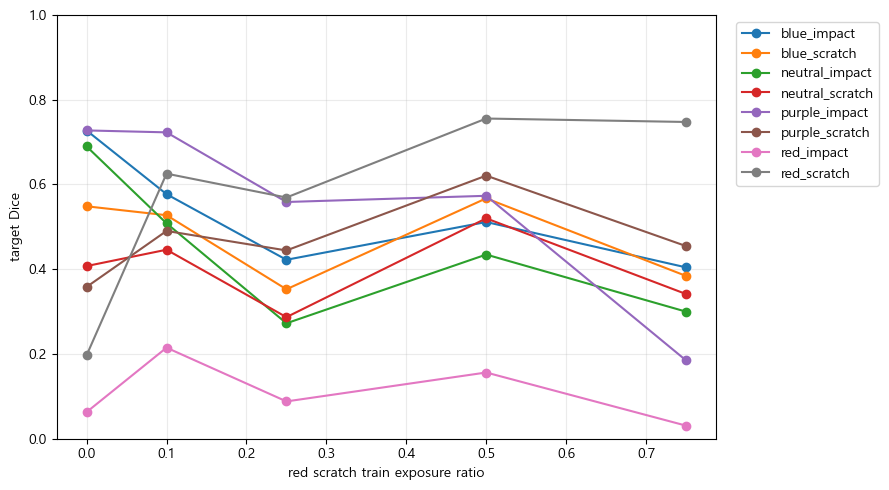

,eval_combo,dice_at_min_ratio,dice_at_max_ratio,delta_max_minus_min,ci95_low,ci95_high,n_seeds
7,red_scratch,0.197019,0.747547,0.550528,0.513226,0.616881,3
5,purple_scratch,0.358276,0.454675,0.096399,-0.068304,0.189126,3
6,red_impact,0.062914,0.030905,-0.032009,-0.061772,0.000000,3
3,neutral_scratch,0.407495,0.341520,-0.065974,-0.177124,0.014045,3
1,blue_scratch,0.548503,0.384226,-0.164277,-0.249918,-0.035474,3
0,blue_impact,0.727344,0.404418,-0.322926,-0.362232,-0.275517,3
2,neutral_impact,0.689773,0.299918,-0.389855,-0.396488,-0.384710,3
4,purple_impact,0.727600,0.184924,-0.542677,-0.812460,-0.323272,3


In [4]:
exposure_path = paths.runs_root / "clean_exposure_ratio_sample_metrics.csv"
exposure_metrics = pd.read_csv(exposure_path)
curve = (
    exposure_metrics.groupby(["model_seed", "exposure_ratio", "eval_combo"])["target_dice"]
    .mean()
    .reset_index()
)
mean_curve = curve.groupby(["exposure_ratio", "eval_combo"])["target_dice"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for combo, part in mean_curve.groupby("eval_combo"):
    part = part.sort_values("exposure_ratio")
    ax.plot(part["exposure_ratio"], part["target_dice"], marker="o", label=combo)
ax.set_xlabel("red scratch train exposure ratio")
ax.set_ylabel("target Dice")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(paths.runs_root / "clean_exposure_ratio_curve.png", dpi=150)
plt.show()

deltas = []
for combo, combo_df in curve.groupby("eval_combo"):
    pivot = combo_df.pivot(index="model_seed", columns="exposure_ratio", values="target_dice")
    min_ratio = min(pivot.columns)
    max_ratio = max(pivot.columns)
    diff = pivot[max_ratio] - pivot[min_ratio]
    ci_low, ci_high = bootstrap_ci(diff.dropna().tolist())
    deltas.append({
        "eval_combo": combo,
        "dice_at_min_ratio": pivot[min_ratio].mean(),
        "dice_at_max_ratio": pivot[max_ratio].mean(),
        "delta_max_minus_min": diff.mean(),
        "ci95_low": ci_low,
        "ci95_high": ci_high,
        "n_seeds": int(diff.dropna().shape[0]),
    })
delta_df = pd.DataFrame(deltas).sort_values("delta_max_minus_min", ascending=False)
delta_df.to_csv(paths.runs_root / "clean_exposure_ratio_delta_summary.csv", index=False, encoding="utf-8-sig")
display(delta_df)

## 26-4. 결론

In [5]:
print("결론: clean target pool 기반 exposure transfer 결과를 저장했습니다.")
print("next notebook: 27_Chap2_2_개선전략_선별.ipynb")

결론: clean target pool 기반 exposure transfer 결과를 저장했습니다.
next notebook: 27_Chap2_2_개선전략_선별.ipynb
